In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [33]:
df = pd.read_csv('hour.csv')
df.shape

(17379, 17)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [35]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [36]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [37]:
df.drop(columns=['instant', 'casual', 'registered', 'atemp', 'dteday'], inplace=True)
df.dtypes

,0
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64
hum,float64


In [38]:
hourly_avg = df.groupby('hr')['cnt'].mean()
(hourly_avg)

,cnt
hr,
0,53.898072
1,33.375691
2,22.869930
3,11.727403
4,6.352941
5,19.889819
6,76.044138
7,212.064649
8,359.011004


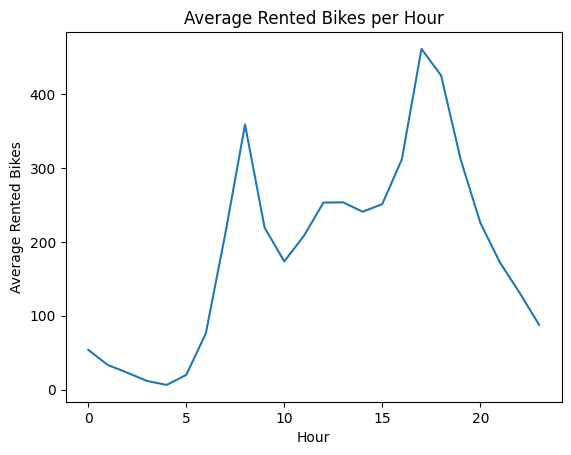

In [39]:
plt.plot(hourly_avg.index, hourly_avg.values)
plt.xlabel('Hour')
plt.ylabel('Average Rented Bikes')
plt.title('Average Rented Bikes per Hour')
plt.show()

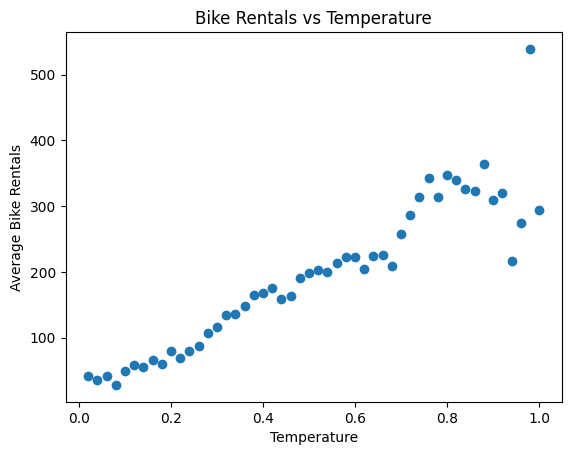

In [40]:
temp_avg = df.groupby("temp")["cnt"].mean()

plt.scatter(temp_avg.index, temp_avg.values)
plt.xlabel("Temperature")
plt.ylabel("Average Bike Rentals")
plt.title("Bike Rentals vs Temperature")
plt.show()

In [41]:
X = df.iloc[:, :-1]
y = df['cnt']

categorical_cols = ['season', 'mnth', 'weekday', 'weathersit']

X = pd.get_dummies(X, columns=categorical_cols)

X['hr_squared'] = X['hr'] ** 2



X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(13903, 35)
(3476, 35)
(13903,)
(3476,)


In [42]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)


print("Linear Regression")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)



rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Linear Regression
MAE: 96.51139228236381
RMSE: 126.35641028522932
R²: 0.4957923568235021
Random Forest
MAE: 31.742552275231155
RMSE: 50.89400834897062
R²: 0.9182009651381675


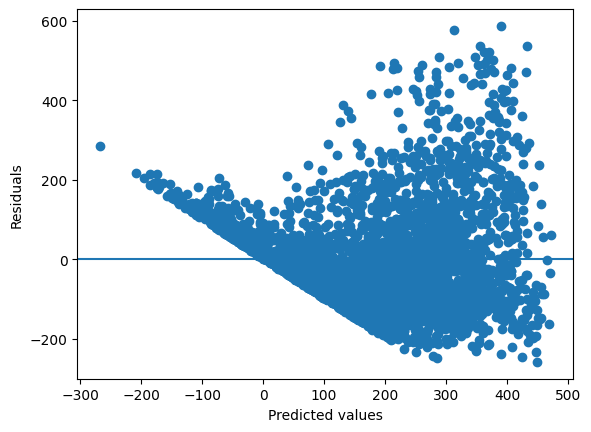

In [43]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()

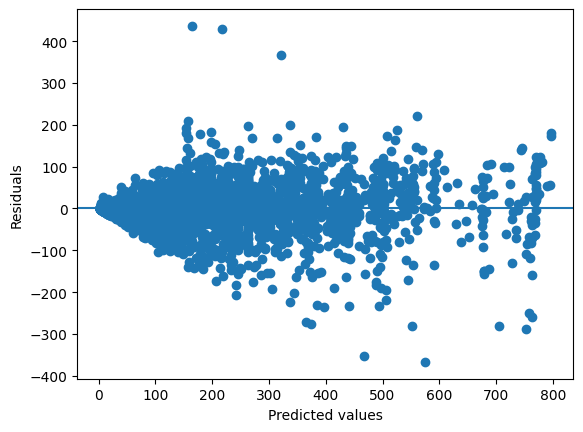

In [44]:
rf_residuals = y_test - rf_pred
plt.scatter(rf_pred, rf_residuals)
plt.axhline(0)
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.show()

In [54]:
real_life = pd.DataFrame([{
    'yr': 1,
    'hr': 12,
    'holiday': 0,
    'workingday': 0,
    'temp': 0.78,
    'hum': 0.55,
    'windspeed': 0.15,

    'season_1': 0,
    'season_2': 0,
    'season_3': 1,
    'season_4': 0,

    'mnth_1': 0,
    'mnth_2': 0,
    'mnth_3': 0,
    'mnth_4': 0,
    'mnth_5': 0,
    'mnth_6': 0,
    'mnth_7': 1,
    'mnth_8': 0,
    'mnth_9': 0,
    'mnth_10': 0,
    'mnth_11': 0,
    'mnth_12': 0,

    'weekday_0': 0,
    'weekday_1': 0,
    'weekday_2': 0,
    'weekday_3': 0,
    'weekday_4': 0,
    'weekday_5': 0,
    'weekday_6': 1,

    'weathersit_1': 1,
    'weathersit_2': 0,
    'weathersit_3': 0,
    'weathersit_4': 0,

    'hr_squared': 18**2
}])

prediction = rf.predict(real_life)[0]

print(f"Predicted bike rentals: {prediction:.0f}")

Predicted bike rentals: 510
